# UNIDAD I: Introducción a algoritmos y estructuras de datos
## ⬆️ Capitulo 2 DSAP: OOP  — Clases y Objetos en Python
### Programación III - Lic. en Sistemas

![Molde](images/pexels-n-voitkevich-6033669.jpg)

[Foto de Nataliya Vaitkevich](https://www.pexels.com/es-es/foto/comida-navidad-navidades-delicioso-6033669/)

---

> **Conexión con Cap. 1:** En el capítulo anterior vimos que *todo en Python es un objeto*.  
> En este capítulo aprendemos a **crear nuestros propios tipos de objetos** usando clases.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/CristianPacifico/prog3-ls-fcad-uner/blob/main/cap02/01_Clases_Objetos_Teoria.ipynb)

## 🎯 Objetivos de aprendizaje

Al finalizar este notebook podrás:

1. **Principios OOP** — Explicar los 4 pilares (encapsulamiento, abstracción, herencia, polimorfismo) y los 3 objetivos de diseño
2. **Anatomía de una clase** — Escribir clases con `__init__`, atributos de instancia, atributos de clase y métodos
3. **Encapsulamiento** — Usar la convención `_atributo` (protegido) y `__atributo` (name mangling)
4. **Métodos especiales** — Implementar `__str__`, `__repr__`, `__eq__`, `__lt__`, `__add__` para integrar objetos con Python
5. **Variables de clase vs instancia** — Identificar el comportamiento y los peligros de mutables como clase-variable

## 📋 Contenidos

| # | Sección | Temas | Sección libro |
|---|---------|-------|---------------|
| 1 | [Principios OOP](#sec1) | 4 pilares, 3 objetivos de diseño, procedural vs OOP | §2.1 |
| 2 | [Anatomía de una Clase](#sec2) | `__init__`, atributos, métodos, `self`, clase TarjetaCredito | §2.2–2.3 |
| 3 | [Métodos Especiales](#sec3) | Dunder methods, operadores, `@property`, `total_ordering` | §2.3 |

**Tiempo estimado:** 90 minutos  
**Nivel:** Intermedio  
**Pre-requisitos:** Cap. 1 (tipos built-in, funciones, clases de excepción básicas)

---

> **💡 Analogía central:** Una **clase** es como el plano de un edificio — define la estructura.  
> Un **objeto** (instancia) es el edificio real construido a partir de ese plano.  
> Podés construir muchos edificios desde el mismo plano, cada uno con su propia dirección.

## ⚙️ Configuración

In [20]:
import sys
import unittest
import functools
import copy
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print(f"Python {sys.version}")
print("Modulos cargados: sys, unittest, functools, copy, matplotlib")

# Validacion de version
assert sys.version_info >= (3, 8), "Se requiere Python 3.8 o superior"
print("Entorno listo para Capitulo 2 - OOP")

Python 3.12.13 | packaged by Anaconda, Inc. | (main, Mar 19 2026, 20:20:58) [GCC 14.3.0]
Modulos cargados: sys, unittest, functools, copy, matplotlib
Entorno listo para Capitulo 2 - OOP


## 1. Principios de la Programación Orientada a Objetos (§2.1) <a id="sec1"></a>

### 🎯 Los 3 Objetivos de Diseño

| Objetivo | Descripción | En Python |
|----------|-------------|-----------|
| **Robustez** | El programa maneja entradas incorrectas sin fallar | `try/except`, validaciones en `__init__` |
| **Adaptabilidad** | El programa se puede modificar con mínimo impacto | Herencia, polimorfismo |
| **Reusabilidad** | Componentes usables en múltiples situaciones | Clases, módulos, composición |

### 🏛️ Los 4 Pilares OOP

| Pilar | Definición | Analogía | Mecanismo Python |
|-------|-----------|---------|-----------------|
| **Encapsulamiento** | Ocultar detalles internos; exponer solo interfaz | Cajero automático — no ves la lógica interna | `_attr`, `__attr`, `@property` |
| **Abstracción** | Modelar lo esencial, ignorar lo irrelevante | Mapa — muestra calles, no cada piedra | Clases, ABCs (§2.7) |
| **Herencia** | Nueva clase que extiende una existente | Empleado hereda de Persona | `class Hijo(Padre):` — Cap. 2 §2.4 |
| **Polimorfismo** | Distintos tipos responden al mismo mensaje | `len([1,2])` y `len("hola")` — mismo mensaje, distintos tipos | Duck typing, `__len__`, ABCs |

> **¿Por qué OOP para estructuras de datos?**  
> Una `ListaEnlazada`, un `Árbol` o una `Tabla Hash` son objetos con estado interno y operaciones definidas.  
> OOP nos permite implementarlos de forma modular, extensible y reutilizable.

In [ ]:
# === Motivación: ¿Por qué OOP? ===
# Versión PROCEDURAL — datos y funciones separados

punto_x, punto_y = 3.0, 4.0

def distancia_origen_proc(x, y):
    return (x**2 + y**2) ** 0.5

def desplazar_proc(x, y, dx, dy):
    return x + dx, y + dy

def punto_str_proc(x, y):
    return f"({x}, {y})"

print("=== Versión Procedural ===")
print(f"Punto:     {punto_str_proc(punto_x, punto_y)}")
print(f"Distancia: {distancia_origen_proc(punto_x, punto_y):.4f}")
punto_x, punto_y = desplazar_proc(punto_x, punto_y, 1, -1)
print(f"Tras mover: {punto_str_proc(punto_x, punto_y)}")

print()


=== Versión Procedural ===
Punto:     (3.0, 4.0)
Distancia: 5.0000
Tras mover: (4.0, 3.0)



Problemas de este enfoque: 

1) Nada impide hacer cosas extrañas.
`punto_x = "hola"  # sin proteccion`

2) Siempre debo tener en cuenta ambas componentes (x,y).

3) Las signaturas de las funciones no son intuitivas.

### Versión basada en OOP

In [23]:

# === Versión OOP — datos y comportamiento encapsulados ===
class Punto:
    """Representa un punto en el plano R²."""

    def __init__(self, x: float = 0.0, y: float = 0.0):
        self._x = float(x)   # _  -> convención "protegido"
        self._y = float(y)

    @property
    def x(self): return self._x

    @property
    def y(self): return self._y

    def distancia_origen(self) -> float:
        return (self._x**2 + self._y**2) ** 0.5

    def desplazar(self, dx: float, dy: float) -> 'Punto':
        """Retorna un nuevo Punto desplazado (objetos inmutables es mas seguro)."""
        return Punto(self._x + dx, self._y + dy)

    def __repr__(self): return f"Punto({self._x}, {self._y})"
    
    def __str__(self):  return f"({self._x}, {self._y})"
    
    def __eq__(self, other):
        if not isinstance(other, Punto): return NotImplemented
        return self._x == other._x and self._y == other._y


print("=== Versión OOP ===")

p = Punto(3, 4)
print(f"Punto:     {p}")
print(f"Distancia: {p.distancia_origen():.4f}")

p2 = p.desplazar(1, -1)

print(f"Tras mover: {p2}")
print(f"Original intacto: {p}")   # los objetos inmutables son seguros
print(f"Son iguales: {p == Punto(3, 4)}")

=== Versión OOP ===
Punto:     (3.0, 4.0)
Distancia: 5.0000
Tras mover: (4.0, 3.0)
Original intacto: (3.0, 4.0)
Son iguales: True


### 🔬 Análisis: Procedural vs OOP

| Aspecto | Procedural | OOP |
|---------|-----------|-----|
| Datos | Variables sueltas (`punto_x`, `punto_y`) | Agrupados en el objeto (`self._x`, `self._y`) |
| Protección | Ninguna (cualquiera modifica `punto_x`) | Convención `_` + `@property` sin setter |
| Cohesión | Funciones por separado | Métodos dentro de la clase |
| Extensión | Copiar y modificar funciones | Herencia (nuevo tipo con `class Punto3D(Punto):`) |
| Python idiom | `len(punto_str(x,y))` — extraño | `len(p)` — natural si define `__len__` |

**Regla de oro:** Si varios datos y funciones siempre van juntos, son candidatos a ser una clase.

## 2. Anatomía de una Clase Python (§2.2–2.3) <a id="sec2"></a>

### 📐 Diagrama de una clase

```text
class NombreClase(ClaseBase):        <-- nombre + herencia (opcional)
    CONSTANTE_CLASE = valor          <-- atributo de clase (compartido)
    
    def __init__(self, arg1, arg2):  <-- constructor
        self._atributo1 = arg1       <-- atributo de instancia (privado convención)
        self._atributo2 = arg2
    
    @property
    def atributo1(self):             <-- getter (acceso de solo lectura)
        return self._atributo1
    
    def metodo(self, param):         <-- método de instancia
        """Docstring del método."""
        ...
    
    def __repr__(self):              <-- representación técnica (para debugger)
        return f"NombreClase({self._atributo1!r})"
    
    def __str__(self):               <-- representación amigable (para print)
        return f"..."
```

### Variables de clase vs variables de instancia

| Tipo | Dónde se define | Compartida entre | Ejemplo |
|------|----------------|-----------------|---------|
| **Clase** | Fuera de `__init__`, en el cuerpo | Todas las instancias | `TASA_IVA = 0.21` |
| **Instancia** | Dentro de `__init__` via `self.` | Solo esa instancia | `self._saldo = 0` |

In [12]:
class Temperatura:
    """
    Representa una temperatura con conversiones entre escalas.

    Atributo de clase: ESCALA_ABSOLUTA_CERO
    Atributos de instancia: _valor_celsius (siempre en Celsius internamente)
    """
    CERO_ABSOLUTO_CELSIUS = -273.15   # atributo de CLASE (constante compartida)
    _instancias_creadas = 0           # atributo de clase (contador mutable)

    def __init__(self, valor: float, escala: str = 'C'):
        """
        Args:
            valor: valor numérico de la temperatura.
            escala: 'C' (Celsius), 'F' (Fahrenheit) o 'K' (Kelvin).
        """
        Temperatura._instancias_creadas += 1
        escala = escala.upper()
        if escala == 'C':
            self._celsius = float(valor)
        elif escala == 'F':
            self._celsius = (valor - 32) * 5 / 9
        elif escala == 'K':
            self._celsius = valor + Temperatura.CERO_ABSOLUTO_CELSIUS
        else:
            raise ValueError(f"Escala desconocida: {escala!r}")
        if self._celsius < Temperatura.CERO_ABSOLUTO_CELSIUS:
            raise ValueError(f"Temperatura por debajo del cero absoluto: {self._celsius:.2f} C")

    @property
    def celsius(self) -> float:
        return self._celsius

    @property
    def fahrenheit(self) -> float:
        return self._celsius * 9 / 5 + 32

    @property
    def kelvin(self) -> float:
        return self._celsius - Temperatura.CERO_ABSOLUTO_CELSIUS

    def __repr__(self):
        return f"Temperatura({self._celsius:.2f}, 'C')"

    def __str__(self):
        return f"{self._celsius:.1f} °C  |  {self.fahrenheit:.1f} °F  |  {self.kelvin:.1f} K"

    def __eq__(self, other):
        if not isinstance(other, Temperatura): return NotImplemented
        return abs(self._celsius - other._celsius) < 1e-9

    def __lt__(self, other):
        if not isinstance(other, Temperatura): return NotImplemented
        return self._celsius < other._celsius

    def __add__(self, grados: float) -> 'Temperatura':
        """Sube la temperatura en `grados` Celsius."""
        return Temperatura(self._celsius + grados)


# --- Demo ---
ebullicion = Temperatura(100, 'C')
cuerpo     = Temperatura(98.6, 'F')
cero_abs   = Temperatura(0, 'K')

print(f"Ebullicion agua: {ebullicion}")
print(f"Temperatura cuerpo: {cuerpo}")
print(f"Cero absoluto: {cero_abs}")
print(f"\nEbullicion > Cuerpo: {ebullicion > cuerpo}")
print(f"Calentada 10 grados: {ebullicion + 10}")
print(f"Instancias creadas: {Temperatura._instancias_creadas}")

try:
    Temperatura(-300, 'C')
except ValueError as e:
    print(f"Error esperado: {e}")

Ebullicion agua: 100.0 °C  |  212.0 °F  |  373.1 K
Temperatura cuerpo: 37.0 °C  |  98.6 °F  |  310.1 K
Cero absoluto: -273.1 °C  |  -459.7 °F  |  0.0 K

Ebullicion > Cuerpo: True
Calentada 10 grados: 110.0 °C  |  230.0 °F  |  383.1 K
Instancias creadas: 4
Error esperado: Temperatura por debajo del cero absoluto: -300.00 C


### 🔍 Análisis: Variables de Clase vs. Variables de Instancia

La clase `Temperatura` ilustra los dos tipos de atributos en Python:

| Concepto | Variable de clase | Variable de instancia |
|----------|------------------|-----------------------|
| Definición | Cuerpo de la clase, fuera de métodos | Dentro de `__init__` (via `self.x = ...`) |
| Almacenamiento | Namespace de la clase | Namespace del objeto |
| Compartido | Sí — todas las instancias ven el mismo valor | No — cada objeto tiene la suya |
| Acceso | `Temperatura.CERO_ABSOLUTO_CELSIUS` o `self.CERO_ABSOLUTO_CELSIUS` | `self._celsius` |
| Uso típico | Constantes, contadores, configuración | Estado particular del objeto |

**Regla de resolución de Python:** cuando se evalúa `self.x`, Python busca primero en el namespace del objeto, luego en el namespace de la clase. Esto permite *shadowing* (una instancia puede "ocultar" un atributo de clase con uno propio).

> ⚠️ **Trampa frecuente:** si el atributo de clase es **mutable** (por ejemplo, una lista), modificarlo via una instancia modifica **todas** las instancias. Véase la celda siguiente.

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# TRAMPA: atributo de clase mutable (lista / dict / set)
# ─────────────────────────────────────────────────────────────────────────────

class ContadorMalo:
    """Cada instancia comparte la MISMA lista — ¡peligroso!"""
    registro = []          # atributo de clase (lista mutable)

    def agregar(self, valor):
        self.registro.append(valor)   # modifica la lista DE LA CLASE


class ContadorBueno:
    """Cada instancia tiene su propia lista — correcto."""
    def __init__(self):
        self.registro = []            # atributo de INSTANCIA

    def agregar(self, valor):
        self.registro.append(valor)


# ── demo del error ──────────────────────────────────────────────────────────
a_malo = ContadorMalo()
b_malo = ContadorMalo()
a_malo.agregar("item-A")
b_malo.agregar("item-B")

print("=== ContadorMalo ===")
print(f"a_malo.registro: {a_malo.registro}")
print(f"b_malo.registro: {b_malo.registro}")   # ¡también tiene item-A!
print(f"Mismo objeto: {a_malo.registro is b_malo.registro}")

# ── demo correcto ────────────────────────────────────────────────────────────
a_bueno = ContadorBueno()
b_bueno = ContadorBueno()
a_bueno.agregar("item-A")
b_bueno.agregar("item-B")

print("\n=== ContadorBueno ===")
print(f"a_bueno.registro: {a_bueno.registro}")
print(f"b_bueno.registro: {b_bueno.registro}")   # solo tiene item-B
print(f"Mismo objeto: {a_bueno.registro is b_bueno.registro}")

# ── inspeccionando el namespace ──────────────────────────────────────────────
print("\n=== Namespaces ===")
print(f"ContadorMalo.__dict__['registro']: {ContadorMalo.__dict__['registro']}")
print(f"a_malo.__dict__: {a_malo.__dict__}")     # vacío — el objeto no tiene 'registro' propio
print(f"a_bueno.__dict__: {a_bueno.__dict__}")   # tiene 'registro' propio

=== ContadorMalo ===
a_malo.registro: ['item-A', 'item-B']
b_malo.registro: ['item-A', 'item-B']
Mismo objeto: True

=== ContadorBueno ===
a_bueno.registro: ['item-A']
b_bueno.registro: ['item-B']
Mismo objeto: False

=== Namespaces ===
ContadorMalo.__dict__['registro']: ['item-A', 'item-B']
a_malo.__dict__: {}
a_bueno.__dict__: {'registro': ['item-A']}


In [14]:
class TarjetaCredito:
    """
    Implementacion del ejemplo §2.3 del libro (CreditCard traducida al español).

    El estado interno usa atributos con un guion bajo (_) para indicar
    que son "protegidos" — no accederlos directamente desde fuera.
    """

    def __init__(self, cliente: str, banco: str, cuenta: str, limite: float):
        """Inicializa una tarjeta de crédito nueva con saldo cero."""
        self._cliente = cliente
        self._banco   = banco
        self._cuenta  = cuenta
        self._limite  = float(limite)
        self._saldo   = 0.0
        self._historial = []   # lista de (tipo, monto, saldo_resultante)

    # ── Propiedades de solo lectura ──────────────────────────────────────────
    @property
    def cliente(self) -> str:   return self._cliente

    @property
    def banco(self) -> str:     return self._banco

    @property
    def cuenta(self) -> str:    return self._cuenta

    @property
    def limite(self) -> float:  return self._limite

    @property
    def saldo(self) -> float:   return self._saldo

    # ── Operaciones de negocio ───────────────────────────────────────────────
    def cargar(self, precio: float) -> bool:
        """
        Carga `precio` a la tarjeta.
        Retorna True si aprobado, False si excede el límite.
        """
        if precio <= 0:
            raise ValueError("El precio debe ser positivo")
        if self._saldo + precio > self._limite:
            return False
        self._saldo += precio
        self._historial.append(('cargo', precio, self._saldo))
        return True

    def pagar(self, monto: float) -> None:
        """Reduce el saldo en `monto`. Lanza ValueError si monto <= 0."""
        if monto <= 0:
            raise ValueError("El pago debe ser un monto positivo")
        self._saldo = max(0.0, self._saldo - monto)
        self._historial.append(('pago', monto, self._saldo))

    def historial(self) -> list:
        """Devuelve copia del historial de transacciones."""
        return list(self._historial)

    # ── Métodos especiales ───────────────────────────────────────────────────
    def __repr__(self):
        return (f"TarjetaCredito({self._cliente!r}, {self._banco!r}, "
                f"{self._cuenta!r}, {self._limite})")

    def __str__(self):
        return (f"Tarjeta [{self._cuenta[-4:]}] — {self._cliente}\n"
                f"  Banco:  {self._banco}\n"
                f"  Saldo:  ${self._saldo:,.2f}  /  Límite: ${self._limite:,.2f}\n"
                f"  Disponible: ${self._limite - self._saldo:,.2f}")

    def __eq__(self, other):
        if not isinstance(other, TarjetaCredito): return NotImplemented
        return self._cuenta == other._cuenta


# ── Demo de uso ──────────────────────────────────────────────────────────────
t1 = TarjetaCredito("Ana Pérez",   "Banco Nacional", "5391-****-1234", 5000)
t2 = TarjetaCredito("Carlos López","Banco Central",  "4111-****-5678", 3000)

# cargos
print(f"Cargo $200   aprobado: {t1.cargar(200)}")
print(f"Cargo $100   aprobado: {t1.cargar(100)}")
print(f"Cargo $5000  aprobado: {t1.cargar(5000)}")  # debe ser False (excede límite)

# pago
t1.pagar(150)

print("\n--- Estado final ---")
print(t1)
print("\n--- Historial ---")
for tipo, monto, saldo in t1.historial():
    simbolo = "+" if tipo == 'pago' else "-"
    print(f"  [{tipo.upper():5s}] {simbolo}${monto:7.2f} | saldo: ${saldo:,.2f}")

print(f"\nrepr: {t1!r}")
print(f"t1 == t2: {t1 == t2}")

Cargo $200   aprobado: True
Cargo $100   aprobado: True
Cargo $5000  aprobado: False

--- Estado final ---
Tarjeta [1234] — Ana Pérez
  Banco:  Banco Nacional
  Saldo:  $150.00  /  Límite: $5,000.00
  Disponible: $4,850.00

--- Historial ---
  [CARGO] -$ 200.00 | saldo: $200.00
  [CARGO] -$ 100.00 | saldo: $300.00
  [PAGO ] +$ 150.00 | saldo: $150.00

repr: TarjetaCredito('Ana Pérez', 'Banco Nacional', '5391-****-1234', 5000.0)
t1 == t2: False


---
## 🔧 Sección 3 — Métodos Especiales (*Dunder Methods*)

Python usa el protocolo de **doble guión bajo** (*dunder* = double underscore) para integrar los objetos con el lenguaje. Al definir estos métodos, tus clases participan de forma natural en operaciones como `print()`, `len()`, comparaciones y operadores aritméticos.

### Catálogo de métodos especiales más usados

| Categoría | Método | Qué activa |
|-----------|--------|-----------|
| **Representación** | `__repr__(self)` | `repr(obj)`, modo interactivo |
| | `__str__(self)` | `str(obj)`, `print(obj)` |
| **Comparación** | `__eq__(self, other)` | `a == b` |
| | `__lt__(self, other)` | `a < b` |
| | `__le__`, `__gt__`, `__ge__` | `<=`, `>`, `>=` |
| **Aritmética** | `__add__(self, other)` | `a + b` |
| | `__sub__`, `__mul__`, `__truediv__` | `-`, `*`, `/` |
| | `__neg__(self)` | `-a` |
| **Contenedor** | `__len__(self)` | `len(obj)` |
| | `__getitem__(self, key)` | `obj[key]` |
| | `__contains__(self, item)` | `item in obj` |
| | `__iter__(self)` | `for x in obj` |
| **Ciclo de vida** | `__init__(self, ...)` | Constructor (inicialización) |
| | `__del__(self)` | Destructor (garbage collection) |
| **Booleano** | `__bool__(self)` | `bool(obj)`, `if obj:` |

> 💡 **`functools.total_ordering`**: si defines `__eq__` y **uno** de los comparadores de orden (`__lt__`, `__le__`, `__gt__`, o `__ge__`), este decorador genera automáticamente los demás.

### La diferencia `__repr__` vs `__str__`

```text
__repr__  →  representación "oficial" — debe ser reproducible (o unívoca)
            Usada en el intérprete interactivo y repr()
            Regla de oro: eval(repr(obj)) == obj  (cuando sea posible)

__str__   →  representación "amigable" — para el usuario final
            Usada por print() y str()
            Si no existe, Python usa __repr__ como fallback
```

In [27]:
import functools

@functools.total_ordering
class Fraccion:
    """
    Fraccion irreducible a/b — demuestra métodos especiales completos.
    
    @total_ordering genera __le__, __gt__, __ge__ a partir de __eq__ + __lt__.
    """

    def __init__(self, numerador: int, denominador: int = 1):
        if denominador == 0:
            raise ZeroDivisionError("El denominador no puede ser cero")
        # normalización: signo siempre en el numerador
        signo = -1 if (numerador * denominador) < 0 else 1
        n, d  = abs(numerador), abs(denominador)
        mcd   = self._mcd(n, d)
        self._num = signo * (n // mcd)
        self._den = d // mcd

    @staticmethod
    def _mcd(a: int, b: int) -> int:
        """Máximo común divisor (algoritmo de Euclides)."""
        while b:
            a, b = b, a % b
        return a

    # ── Propiedades ─────────────────────────────────────────────────────────
    @property
    def numerador(self):   return self._num

    @property
    def denominador(self): return self._den

    # ── Representación ─────────────────────────────────────────────────────
    def __repr__(self):
        return f"Fraccion({self._num}, {self._den})"

    def __str__(self):
        return str(self._num) if self._den == 1 else f"{self._num}/{self._den}"

    # ── Comparación (total_ordering usa estos dos para generar el resto) ───
    def __eq__(self, other):
        if isinstance(other, int):
            other = Fraccion(other)
        if not isinstance(other, Fraccion): return NotImplemented
        return self._num * other._den == other._num * self._den

    def __lt__(self, other):
        if isinstance(other, int):
            other = Fraccion(other)
        if not isinstance(other, Fraccion): return NotImplemented
        return self._num * other._den < other._num * self._den

    # ── Aritmética ─────────────────────────────────────────────────────────
    def __add__(self, other):
        if isinstance(other, int): other = Fraccion(other)
        return Fraccion(self._num * other._den + other._num * self._den,
                        self._den * other._den)

    def __radd__(self, other):        # soporta  5 + Fraccion(1,2)
        return self + other

    def __sub__(self, other):
        if isinstance(other, int): other = Fraccion(other)
        return Fraccion(self._num * other._den - other._num * self._den,
                        self._den * other._den)

    def __mul__(self, other):
        if isinstance(other, int): other = Fraccion(other)
        return Fraccion(self._num * other._num, self._den * other._den)

    def __truediv__(self, other):
        if isinstance(other, int): other = Fraccion(other)
        return Fraccion(self._num * other._den, self._den * other._num)

    def __neg__(self):
        return Fraccion(-self._num, self._den)

    # ── Bool / float ────────────────────────────────────────────────────────
    def __bool__(self):
        return self._num != 0

    def __float__(self):
        return self._num / self._den


# ── Demo ─────────────────────────────────────────────────────────────────────
a = Fraccion(3, 4)
b = Fraccion(1, 2)

print(f"a = {a}    b = {b}")
print(f"a + b = {a + b}")
print(f"a - b = {a - b}")
print(f"a * b = {a * b}")
print(f"a / b = {a / b}")
print(f"-a    = {-a}")
print(f"5 + b = {5 + b}")
print()
print(f"a == b:  {a == b}")
print(f"a >  b:  {a > b}")    # generado por @total_ordering
print(f"a <= b:  {a <= b}")   # generado por @total_ordering
print()
print(f"float(a) = {float(a)}")
print(f"bool(Fraccion(0)): {bool(Fraccion(0))}")
print(f"repr(a): {repr(a)}")

# Verificar que la reducción funciona
print(f"\nFraccion(6, 4) = {Fraccion(6, 4)}")   # debe ser 3/2
print(f"Fraccion(-3, -9) = {Fraccion(-3, -9)}") # debe ser 1/3

a = 3/4    b = 1/2
a + b = 5/4
a - b = 1/4
a * b = 3/8
a / b = 3/2
-a    = -3/4
5 + b = 11/2

a == b:  False
a >  b:  True
a <= b:  False

float(a) = 0.75
bool(Fraccion(0)): False
repr(a): Fraccion(3, 4)

Fraccion(6, 4) = 3/2
Fraccion(-3, -9) = 1/3


---
## 🧪 Tests Unitarios — `unittest`

Los tests automatizan la verificación de comportamiento correcto. Aplicamos la metodología **AAA** (Arrange → Act → Assert) para cada caso de prueba.

In [16]:
import unittest

class TestTemperatura(unittest.TestCase):

    def test_celsius_inicial(self):
        t = Temperatura(25)
        self.assertAlmostEqual(t.celsius, 25.0)

    def test_conversion_fahrenheit_a_celsius(self):
        t = Temperatura(32, 'F')
        self.assertAlmostEqual(t.celsius, 0.0, places=9)

    def test_conversion_kelvin_a_celsius(self):
        t = Temperatura(273.15, 'K')
        self.assertAlmostEqual(t.celsius, 0.0, places=9)

    def test_propiedad_fahrenheit(self):
        t = Temperatura(0)
        self.assertAlmostEqual(t.fahrenheit, 32.0)

    def test_cero_absoluto_lanza_error(self):
        with self.assertRaises(ValueError):
            Temperatura(-300, 'C')

    def test_escala_invalida_lanza_error(self):
        with self.assertRaises(ValueError):
            Temperatura(25, 'X')

    def test_suma(self):
        t = Temperatura(20) + 5
        self.assertAlmostEqual(t.celsius, 25.0)

    def test_igualdad(self):
        t1 = Temperatura(100)
        t2 = Temperatura(212, 'F')
        self.assertEqual(t1, t2)

    def test_orden(self):
        t_fria  = Temperatura(0)
        t_calid = Temperatura(30)
        self.assertLess(t_fria, t_calid)
        self.assertGreater(t_calid, t_fria)


class TestTarjetaCredito(unittest.TestCase):

    def setUp(self):
        self.tc = TarjetaCredito("Ana", "Banco X", "1234-5678", 1000.0)

    def test_saldo_inicial_cero(self):
        self.assertEqual(self.tc.saldo, 0.0)

    def test_cargo_actualiza_saldo(self):
        self.tc.cargar(200)
        self.assertAlmostEqual(self.tc.saldo, 200.0)

    def test_cargo_rechazado_si_excede_limite(self):
        resultado = self.tc.cargar(1500)
        self.assertFalse(resultado)
        self.assertEqual(self.tc.saldo, 0.0)

    def test_pago_reduce_saldo(self):
        self.tc.cargar(500)
        self.tc.pagar(200)
        self.assertAlmostEqual(self.tc.saldo, 300.0)

    def test_pago_invalido_lanza_error(self):
        with self.assertRaises(ValueError):
            self.tc.pagar(-50)

    def test_historial_registra_operaciones(self):
        self.tc.cargar(100)
        self.tc.pagar(50)
        h = self.tc.historial()
        self.assertEqual(len(h), 2)
        self.assertEqual(h[0][0], 'cargo')
        self.assertEqual(h[1][0], 'pago')


class TestFraccion(unittest.TestCase):

    def test_reduccion(self):
        f = Fraccion(6, 4)
        self.assertEqual(str(f), "3/2")

    def test_suma(self):
        self.assertEqual(Fraccion(1, 2) + Fraccion(1, 3), Fraccion(5, 6))

    def test_multiplicacion(self):
        self.assertEqual(Fraccion(2, 3) * Fraccion(3, 4), Fraccion(1, 2))

    def test_comparacion_orden(self):
        self.assertLess(Fraccion(1, 3), Fraccion(1, 2))
        self.assertGreater(Fraccion(3, 4), Fraccion(1, 2))

    def test_denominador_cero(self):
        with self.assertRaises(ZeroDivisionError):
            Fraccion(1, 0)


# ── Ejecutar desde Jupyter ────────────────────────────────────────────────────
loader = unittest.TestLoader()
suite  = unittest.TestSuite()
for cls in [TestTemperatura, TestTarjetaCredito, TestFraccion]:
    suite.addTests(loader.loadTestsFromTestCase(cls))

runner = unittest.TextTestRunner(verbosity=2)
result = runner.run(suite)

test_celsius_inicial (__main__.TestTemperatura.test_celsius_inicial) ... ok
test_cero_absoluto_lanza_error (__main__.TestTemperatura.test_cero_absoluto_lanza_error) ... ok
test_conversion_fahrenheit_a_celsius (__main__.TestTemperatura.test_conversion_fahrenheit_a_celsius) ... ok
test_conversion_kelvin_a_celsius (__main__.TestTemperatura.test_conversion_kelvin_a_celsius) ... ok
test_escala_invalida_lanza_error (__main__.TestTemperatura.test_escala_invalida_lanza_error) ... ok
test_igualdad (__main__.TestTemperatura.test_igualdad) ... ok
test_orden (__main__.TestTemperatura.test_orden) ... ok
test_propiedad_fahrenheit (__main__.TestTemperatura.test_propiedad_fahrenheit) ... ok
test_suma (__main__.TestTemperatura.test_suma) ... ok
test_cargo_actualiza_saldo (__main__.TestTarjetaCredito.test_cargo_actualiza_saldo) ... ok
test_cargo_rechazado_si_excede_limite (__main__.TestTarjetaCredito.test_cargo_rechazado_si_excede_limite) ... ok
test_historial_registra_operaciones (__main__.TestTarjetaC

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# INTROSPECCIÓN: herramientas Python para explorar objetos
# ─────────────────────────────────────────────────────────────────────────────

t = Temperatura(37)
f = Fraccion(3, 4)
tc = TarjetaCredito("María", "BancoPy", "9999", 2000)

print("=== type() ===")
print(type(t), type(f), type(tc))

print("\n=== isinstance() ===")
print(f"type de Temperatura es float: {isinstance(t, float)}")
print(f"type de Fraccion es object:   {isinstance(f, object)}")  # todo hereda de object

print("\n=== __dict__ (namespace del objeto) ===")
print(f"t.__dict__ : {t.__dict__}")
print(f"tc.__dict__: {tc.__dict__}")

print("\n=== dir() — atributos + métodos ===")
attrs_publicos = [a for a in dir(f) if not a.startswith('_')]
print(f"Fraccion (público): {attrs_publicos}")

print("\n=== __class__.__mro__ (Method Resolution Order) ===")
print(Temperatura.__mro__)  # Temperatura -> object

print("\n=== Acceso seguro a propiedades ===")
print(f"hasattr(tc, 'saldo'): {hasattr(tc, 'saldo')}")
print(f"getattr(tc, 'banco', 'N/A'): {getattr(tc, 'banco', 'N/A')}")

=== type() ===
<class '__main__.Temperatura'> <class '__main__.Fraccion'> <class '__main__.TarjetaCredito'>

=== isinstance() ===
type de Temperatura es float: False
type de Fraccion es object:   True

=== __dict__ (namespace del objeto) ===
t.__dict__ : {'_celsius': 37.0}
tc.__dict__: {'_cliente': 'María', '_banco': 'BancoPy', '_cuenta': '9999', '_limite': 2000.0, '_saldo': 0.0, '_historial': []}

=== dir() — atributos + métodos ===
Fraccion (público): ['denominador', 'numerador']

=== __class__.__mro__ (Method Resolution Order) ===
(<class '__main__.Temperatura'>, <class 'object'>)

=== Acceso seguro a propiedades ===
hasattr(tc, 'saldo'): True
getattr(tc, 'banco', 'N/A'): BancoPy


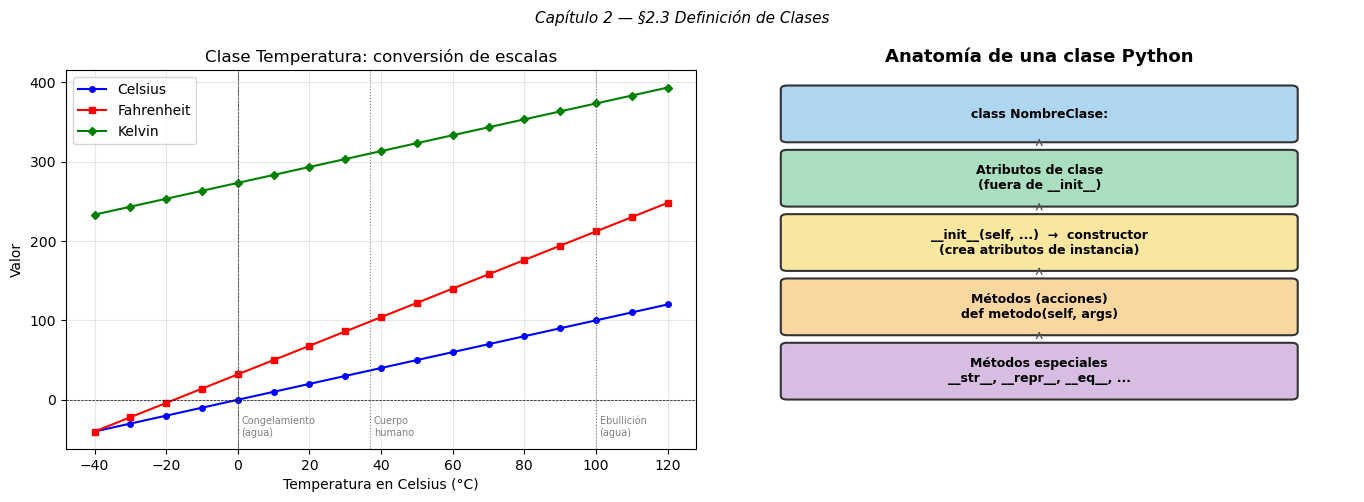

Gráfico guardado como clase_anatomia.png


In [18]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Gráfico 1: Conversión de temperaturas ─────────────────────────────────
celsius_vals = list(range(-40, 121, 10))
temps  = [Temperatura(c) for c in celsius_vals]
fahr   = [t.fahrenheit for t in temps]
kelvin = [t.kelvin     for t in temps]

ax = axes[0]
ax.plot(celsius_vals, celsius_vals, 'b-o', markersize=4, label='Celsius')
ax.plot(celsius_vals, fahr,         'r-s', markersize=4, label='Fahrenheit')
ax.plot(celsius_vals, kelvin,       'g-D', markersize=4, label='Kelvin')
ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax.axvline(0, color='black', linewidth=0.5, linestyle='--')
ax.set_xlabel('Temperatura en Celsius (°C)')
ax.set_ylabel('Valor')
ax.set_title('Clase Temperatura: conversión de escalas')
ax.legend()
ax.grid(True, alpha=0.3)
for c_val, c_special in [(0, 'Congelamiento\n(agua)'), (100, 'Ebullición\n(agua)'), (37, 'Cuerpo\nhumano')]:
    ax.axvline(c_val, color='gray', linewidth=0.8, linestyle=':')
    ax.text(c_val + 1, ax.get_ylim()[0] if ax.get_ylim()[0] > -50 else -50 + 5,
            c_special, fontsize=7, color='gray')

# ── Gráfico 2: Diagrama de componentes de una clase ───────────────────────
ax2 = axes[1]
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 10)
ax2.axis('off')
ax2.set_title('Anatomía de una clase Python', fontsize=13, fontweight='bold')

def box(ax, x, y, w, h, txt, color):
    rect = mpatches.FancyBboxPatch((x, y), w, h,
                                    boxstyle="round,pad=0.1",
                                    facecolor=color, edgecolor='#333', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, txt, ha='center', va='center',
            fontsize=9, fontweight='bold', wrap=True)

# clase header
box(ax2, 1, 8.2, 8, 1.3, 'class NombreClase:', '#AED6F1')
# atributos de clase
box(ax2, 1, 6.5, 8, 1.3, 'Atributos de clase\n(fuera de __init__)', '#A9DFBF')
# __init__
box(ax2, 1, 4.8, 8, 1.3, '__init__(self, ...)  →  constructor\n(crea atributos de instancia)', '#F9E79F')
# métodos
box(ax2, 1, 3.1, 8, 1.3, 'Métodos (acciones)\ndef metodo(self, args)', '#FAD7A0')
# métodos especiales
box(ax2, 1, 1.4, 8, 1.3, 'Métodos especiales\n__str__, __repr__, __eq__, ...', '#D7BDE2')

flechas_y = [8.2, 6.5, 4.8, 3.1]
for y in flechas_y:
    ax2.annotate('', xy=(5, y), xytext=(5, y - 0.05),
                 arrowprops=dict(arrowstyle='->', color='#555'))

fig.tight_layout(pad=2)
plt.suptitle('Capítulo 2 — §2.3 Definición de Clases', y=1.02, fontsize=11, style='italic')
plt.savefig('clase_anatomia.png', bbox_inches='tight', dpi=100)
plt.show()
print("Gráfico guardado como clase_anatomia.png")

---
## 📋 Resumen del Notebook

### Conceptos clave del Capítulo §2.1–2.3

| Concepto | Descripción | Ejemplo |
|----------|-------------|---------|
| **Clase** | Plantilla que define estado + comportamiento | `class Temperatura:` |
| **Objeto / Instancia** | Concreción específica de una clase | `t = Temperatura(37)` |
| **Atributo de instancia** | Variable propia de cada objeto | `self._celsius` |
| **Atributo de clase** | Variable compartida por todas las instancias | `CERO_ABSOLUTO_CELSIUS` |
| **Constructor** | `__init__` — inicializa el estado del objeto | `def __init__(self, val):` |
| **Property** | Getter/setter declarativo con `@property` | `@property def celsius(self):` |
| **Método especial** | Integra el objeto con los operadores Python | `__str__`, `__add__`, `__eq__` |
| **total_ordering** | Decorador que genera comparadores faltantes | `@functools.total_ordering` |

### Los 4 pilares OOP aplicados en este notebook

| Pilar | Dónde se vio |
|-------|-------------|
| **Encapsulamiento** | `_atributo` — acceso controlado via `@property` |
| **Abstracción** | La interfaz pública (`cargar`, `celsius`) oculta la implementación |
| **Polimorfismo** | `__eq__` acepta `int` y `Fraccion`; `__add__` retorna nuevo objeto |
| **Herencia** | Vista en MRO: toda clase hereda de `object` (base en §2.4) |

---
## ✅ Autoevaluación

Antes de continuar con el Notebook 2 (Herencia), verificá que podés:

- [ ] Explicar la diferencia entre clase e instancia con un ejemplo propio
- [ ] Crear una clase con `__init__`, `@property` y al menos 3 métodos especiales
- [ ] Describir qué ocurre si usás una lista mutable como atributo de clase
- [ ] Escribir un test unitario para verificar el comportamiento de `TarjetaCredito`
- [ ] Usar `functools.total_ordering` para ordenar objetos personalizados

## 📚 Referencias y Conexiones

### Fuentes del capítulo
- Goodrich, Tamassia & Goldwasser — *Data Structures and Algorithms in Python*, Cap. 2:
  - §2.1 Goals, Principles, and Patterns
  - §2.2 Software Development
  - §2.3 Class Definitions
- [Python Documentation — Data Model](https://docs.python.org/3/reference/datamodel.html) (métodos especiales)
- [PEP 3107 — Function Annotations](https://peps.python.org/pep-3107/) (type hints)
- [functools.total_ordering](https://docs.python.org/3/library/functools.html#functools.total_ordering)

### Continuación en este capítulo

| Notebook | Tema | Secciones |
|----------|------|-----------|
| **Notebook 2/3** | Herencia y Encapsulamiento | §2.4, §2.5 |
| **Notebook 3/3** | Polimorfismo y ADTs (ABCs) | §2.7 |
| **Ejercicios Clase 1** | Práctica guiada: Clases y Herencia | §2.3–2.4 |
| **Ejercicios Clase 2** | Práctica guiada: Polimorfismo y ADTs | §2.7 |


---

© 2026 Cátedra Programación III — Lic. en Sistemas

Este notebook se distribuye bajo licencia [CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/).
